# Step 1 — Register Hypothesis Verification

**Claim to test.** The L-structural family (length, punctuation, repetition, emoji, caps) works on Pantip because it acts as an indirect proxy for the *register/politeness* signal observed in the 5/12 report — sockpuppets vs. non-sockpuppets differ in their use of Thai politeness markers (`ค่ะ`, `ครับ`, `ผม`, `ดิฉัน`, etc.).

**If the claim holds:** per-user politeness-marker counts should correlate with L-structural feature values, AND should themselves discriminate sock vs. non-sock at a level comparable to L-structural classifier performance (~F1 0.65–0.70).

**If the claim does not hold:** the L-structural finding stays as-is (still valid), but the unified story with 5/12 is abandoned.

**Inputs**
- `Karin_dataset/00_Datasets.txt` — raw posts (used to count politeness markers per user)
- `phase2_train_exp1.csv` / `phase2_test_exp1.csv` — user-level Lindsey features + labels (used to join structural features and labels onto users)

**Outputs**
- `step1_register_per_user.csv` — per-user politeness-marker counts/rates + L-structural features + label
- `step1_register_correlations.csv` — Spearman correlations between politeness measures and each L-structural feature
- `step1_register_discrimination.csv` — Mann-Whitney U test of politeness measures (sock vs non-sock)
- `step1_register_plot.png` — boxplots of politeness rates by class

**Decision rule**
- *Strong support*: any politeness measure has Spearman |ρ| ≥ 0.3 with at least one L-structural feature AND discriminates sock vs non-sock at p < 0.01.
- *Weak support*: significant discrimination (p < 0.05) but |ρ| < 0.3 with structural features. Register signal exists but structural family is capturing it via a different route.
- *No support*: no significant discrimination. Walk back the unified-story claim.

## Cell 1 — Imports and config

In [ ]:
import json
import re
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, mannwhitneyu

DATA_DIR  = Path('../Karin_dataset')
POSTS_FILE = DATA_DIR / '00_Datasets.txt'

# We use Exp 1 train+test merged to maximize user coverage for the correlation analysis.
# (We are not training a classifier here — just describing whether the per-user register
# signal exists and whether it correlates with L-structural features.)
PHASE2_TRAIN = Path('phase2_train_exp1.csv')
PHASE2_TEST  = Path('phase2_test_exp1.csv')

OUT_DIR = Path('.')


## Cell 2 — Define politeness markers and counting logic

In [2]:
# ── Thai politeness markers (from 5/12 report + standard Thai register inventory) ──
# Three groups so we can test whether one drives the signal more than others.

POLITE_PARTICLES = ['ค่ะ', 'คะ', 'ครับ', 'ค๊า', 'จ้า', 'จ๋า', 'นะคะ', 'นะครับ']
FORMAL_PRONOUNS  = ['ผม', 'ดิฉัน', 'ฉัน', 'หนู', 'ข้าพเจ้า']
POLITE_VERBS     = ['ขอบคุณ', 'ขออนุญาต', 'ขอโทษ', 'รบกวน', 'กรุณา']

ALL_MARKERS = {
    'particles': POLITE_PARTICLES,
    'pronouns':  FORMAL_PRONOUNS,
    'verbs':     POLITE_VERBS,
}
ALL_MARKERS_FLAT = sum(ALL_MARKERS.values(), [])

def count_markers(text, markers):
    """Count total occurrences of any marker in `markers` within `text`.
    Uses substring matching — Thai script has no word boundaries.
    Particles in Thai are typically sentence-final or standalone, so substring
    matching is reasonable for the particle group."""
    if not isinstance(text, str) or not text:
        return 0
    return sum(text.count(m) for m in markers)

print('Marker groups:')
for k, v in ALL_MARKERS.items():
    print(f'  {k:10s} ({len(v)}): {v}')


Marker groups:
  particles  (8): ['ค่ะ', 'คะ', 'ครับ', 'ค๊า', 'จ้า', 'จ๋า', 'นะคะ', 'นะครับ']
  pronouns   (5): ['ผม', 'ดิฉัน', 'ฉัน', 'หนู', 'ข้าพเจ้า']
  verbs      (5): ['ขอบคุณ', 'ขออนุญาต', 'ขอโทษ', 'รบกวน', 'กรุณา']


## Cell 3 — Load posts and compute per-user politeness counts

In [3]:
with open(POSTS_FILE, 'r', encoding='utf-8-sig') as f:
    records = json.load(f)

posts = pd.json_normalize(records)
posts['user_id'] = posts['user_id'].astype(int)

# Build the same combined text as Phase II (thread_name + messages)
if 'thread_name' in posts.columns:
    posts['text'] = (posts['thread_name'].fillna('').astype(str) + ' ' +
                     posts['messages'].fillna('').astype(str)).str.strip()
else:
    posts['text'] = posts['messages'].fillna('').astype(str).str.strip()

print(f'Posts: {len(posts):,}  Users: {posts.user_id.nunique():,}')

# Per-post counts for each marker group
for grp_name, markers in ALL_MARKERS.items():
    posts[f'cnt_{grp_name}'] = posts['text'].apply(lambda t: count_markers(t, markers))
posts['cnt_total'] = posts[[f'cnt_{g}' for g in ALL_MARKERS]].sum(axis=1)

# Aggregate to user level
agg = posts.groupby('user_id').agg(
    n_comments=('text', 'size'),
    total_chars=('text', lambda s: s.str.len().sum()),
    particles_count=('cnt_particles', 'sum'),
    pronouns_count =('cnt_pronouns',  'sum'),
    verbs_count    =('cnt_verbs',     'sum'),
    total_markers  =('cnt_total',     'sum'),
).reset_index()

# Rates — normalized by comments and by total characters
agg['particles_per_comment'] = agg['particles_count'] / agg['n_comments']
agg['pronouns_per_comment']  = agg['pronouns_count']  / agg['n_comments']
agg['verbs_per_comment']     = agg['verbs_count']     / agg['n_comments']
agg['markers_per_comment']   = agg['total_markers']   / agg['n_comments']

# Char-normalized rate (per 1000 chars) — protects against very-long-post users
agg['markers_per_1k_chars'] = agg['total_markers'] / agg['total_chars'].replace(0, np.nan) * 1000
agg['markers_per_1k_chars'] = agg['markers_per_1k_chars'].fillna(0)

# Binary "has any politeness marker"
agg['has_any_marker'] = (agg['total_markers'] > 0).astype(int)

print(agg.describe()[['particles_count','pronouns_count','verbs_count',
                       'markers_per_comment','markers_per_1k_chars']].round(3))


Posts: 95,904  Users: 12,954
       particles_count  pronouns_count  verbs_count  markers_per_comment  \
count        12954.000       12954.000    12954.000            12954.000   
mean            10.553           2.566        0.498                2.437   
std             33.973          10.785        2.335                3.348   
min              0.000           0.000        0.000                0.000   
25%              1.000           0.000        0.000                0.746   
50%              3.000           0.000        0.000                1.522   
75%              8.000           1.000        0.000                3.000   
max           1259.000         442.000      107.000               76.000   

       markers_per_1k_chars  
count             12954.000  
mean                  9.737  
std                   9.464  
min                   0.000  
25%                   3.030  
50%                   7.427  
75%                  13.889  
max                 181.818  


## Cell 4 — Join with L-structural features and labels

In [4]:
train = pd.read_csv(PHASE2_TRAIN)
test  = pd.read_csv(PHASE2_TEST)
phase2 = pd.concat([train, test], ignore_index=True)

L_STRUCTURAL = ['emoji_mean', 'emoji_max', 'emoji_std', 'emoji_sum',
                'length_mean', 'length_max', 'length_std', 'length_sum',
                'repetition_mean', 'repetition_max', 'repetition_std', 'repetition_sum',
                'punctuation_mean', 'punctuation_max', 'punctuation_std', 'punctuation_sum',
                'caps_mean', 'caps_max', 'caps_std', 'caps_sum']

keep = ['user_id', 'label'] + L_STRUCTURAL
joined = phase2[keep].merge(agg, on='user_id', how='inner')

joined.to_csv('step1_register_per_user.csv', index=False)
print(f'Joined per-user dataframe: {joined.shape}')
print(f'  sockpuppets: {int(joined.label.sum())}  non-sock: {int((1-joined.label).sum())}')
joined.head()


Joined per-user dataframe: (280, 34)
  sockpuppets: 140  non-sock: 140


,user_id,label,emoji_mean,emoji_max,emoji_std,emoji_sum,length_mean,length_max,length_std,length_sum,...,particles_count,pronouns_count,verbs_count,total_markers,particles_per_comment,pronouns_per_comment,verbs_per_comment,markers_per_comment,markers_per_1k_chars,has_any_marker
0,781291,0,0.0,0.0,0.0,0.0,0.175,0.4,0.178536,0.7,...,6,0,0,6,1.500000,0.00,0.000000,1.5,3.183024,1
1,955704,0,0.0,0.0,0.0,0.0,0.000,0.0,0.000000,0.0,...,0,0,0,0,0.000000,0.00,0.000000,0.0,0.000000,0
2,1636867,0,0.0,0.0,0.0,0.0,0.000,0.0,0.000000,0.0,...,4,0,0,4,4.000000,0.00,0.000000,4.0,19.323671,1
3,1698361,0,0.0,0.0,0.0,0.0,0.000,0.0,0.000000,0.0,...,5,1,0,6,1.250000,0.25,0.000000,1.5,18.867925,1
4,2066757,0,0.0,0.0,0.0,0.0,0.000,0.0,0.000000,0.0,...,2,0,1,3,0.333333,0.00,0.166667,0.5,4.059540,1


## Cell 5 — Does politeness discriminate sock vs non-sock?

In [5]:
POLITENESS_COLS = [
    'particles_count', 'pronouns_count', 'verbs_count', 'total_markers',
    'particles_per_comment', 'pronouns_per_comment', 'verbs_per_comment',
    'markers_per_comment', 'markers_per_1k_chars', 'has_any_marker',
]

rows = []
sock     = joined[joined.label == 1]
non_sock = joined[joined.label == 0]

for col in POLITENESS_COLS:
    s_vals = sock[col].values
    n_vals = non_sock[col].values
    if len(np.unique(np.concatenate([s_vals, n_vals]))) < 2:
        rows.append({'measure': col, 'sock_mean': s_vals.mean(),
                     'nonsock_mean': n_vals.mean(),
                     'u_stat': np.nan, 'p_value': np.nan,
                     'direction': 'flat'})
        continue
    u, p = mannwhitneyu(s_vals, n_vals, alternative='two-sided')
    direction = 'sock < non-sock' if s_vals.mean() < n_vals.mean() else 'sock > non-sock'
    rows.append({
        'measure': col,
        'sock_mean':     round(float(s_vals.mean()), 4),
        'nonsock_mean':  round(float(n_vals.mean()), 4),
        'u_stat':        round(float(u), 1),
        'p_value':       float(p),
        'direction':     direction,
    })

disc = pd.DataFrame(rows).sort_values('p_value')
disc.to_csv('step1_register_discrimination.csv', index=False)
print('Discrimination (Mann-Whitney U) — sock vs non-sock:')
print(disc.to_string(index=False))

# 5/12 prediction: politeness should be lower in sockpuppets ("sock < non-sock")


Discrimination (Mann-Whitney U) — sock vs non-sock:
              measure  sock_mean  nonsock_mean  u_stat      p_value       direction
        total_markers    16.4714       52.4357  6387.0 4.476169e-07 sock < non-sock
      particles_count    14.1214       41.2071  6401.0 4.930621e-07 sock < non-sock
       pronouns_count     1.9786        9.9286  6946.5 2.436709e-06 sock < non-sock
          verbs_count     0.3714        1.3000  7685.5 3.621887e-05 sock < non-sock
    verbs_per_comment     0.0274        0.0537  7867.0 1.623151e-04 sock < non-sock
 pronouns_per_comment     0.3073        0.2773  7668.5 4.330349e-04 sock > non-sock
 markers_per_1k_chars    11.9002       10.3642 10601.5 2.369041e-01 sock > non-sock
  markers_per_comment     2.0946        2.1615  9045.0 2.648848e-01 sock < non-sock
particles_per_comment     1.7599        1.8305  9255.0 4.209252e-01 sock < non-sock
       has_any_marker     0.9143        0.9071  9870.0 8.354586e-01 sock > non-sock


## Cell 6 — Correlate politeness with each L-structural feature

In [6]:
rows = []
for pol_col in POLITENESS_COLS:
    for feat_col in L_STRUCTURAL:
        rho, p = spearmanr(joined[pol_col], joined[feat_col])
        rows.append({
            'politeness':    pol_col,
            'structural':    feat_col,
            'spearman_rho':  round(float(rho), 4) if not np.isnan(rho) else np.nan,
            'p_value':       float(p) if not np.isnan(p) else np.nan,
            'abs_rho':       round(abs(float(rho)), 4) if not np.isnan(rho) else 0,
        })

corr = pd.DataFrame(rows).sort_values('abs_rho', ascending=False)
corr.to_csv('step1_register_correlations.csv', index=False)

print('Top 20 |Spearman ρ| between politeness measures and L-structural features:')
print(corr.head(20)[['politeness','structural','spearman_rho','p_value']].to_string(index=False))

print(f'\nCorrelations with |ρ| ≥ 0.3: {int((corr.abs_rho >= 0.3).sum())} of {len(corr)}')
print(f'Correlations with |ρ| ≥ 0.5: {int((corr.abs_rho >= 0.5).sum())}')


Top 20 |Spearman ρ| between politeness measures and L-structural features:
     politeness      structural  spearman_rho      p_value
 pronouns_count  repetition_sum        0.5360 3.180008e-22
 pronouns_count  repetition_max        0.5052 1.523040e-19
  total_markers  repetition_sum        0.5002 3.948246e-19
  total_markers      length_std        0.4787 1.922523e-17
  total_markers  repetition_max        0.4732 4.977424e-17
  total_markers      length_sum        0.4708 7.456056e-17
particles_count  repetition_sum        0.4678 1.248742e-16
 pronouns_count      length_sum        0.4671 1.401140e-16
particles_count      length_std        0.4598 4.711462e-16
particles_count      length_sum        0.4584 5.924297e-16
 pronouns_count  repetition_std        0.4502 2.222102e-15
 pronouns_count      length_std        0.4439 5.973895e-15
 pronouns_count repetition_mean        0.4433 6.560206e-15
particles_count  repetition_max        0.4404 1.039039e-14
  total_markers  repetition_std        0

/tmp/ipykernel_181365/2953001393.py:4: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(joined[pol_col], joined[feat_col])


## Cell 7 — Visualize the distributions

/tmp/ipykernel_181365/2640353828.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_181365/2640353828.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_181365/2640353828.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
/tmp/ipykernel_181365/2640353828.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for

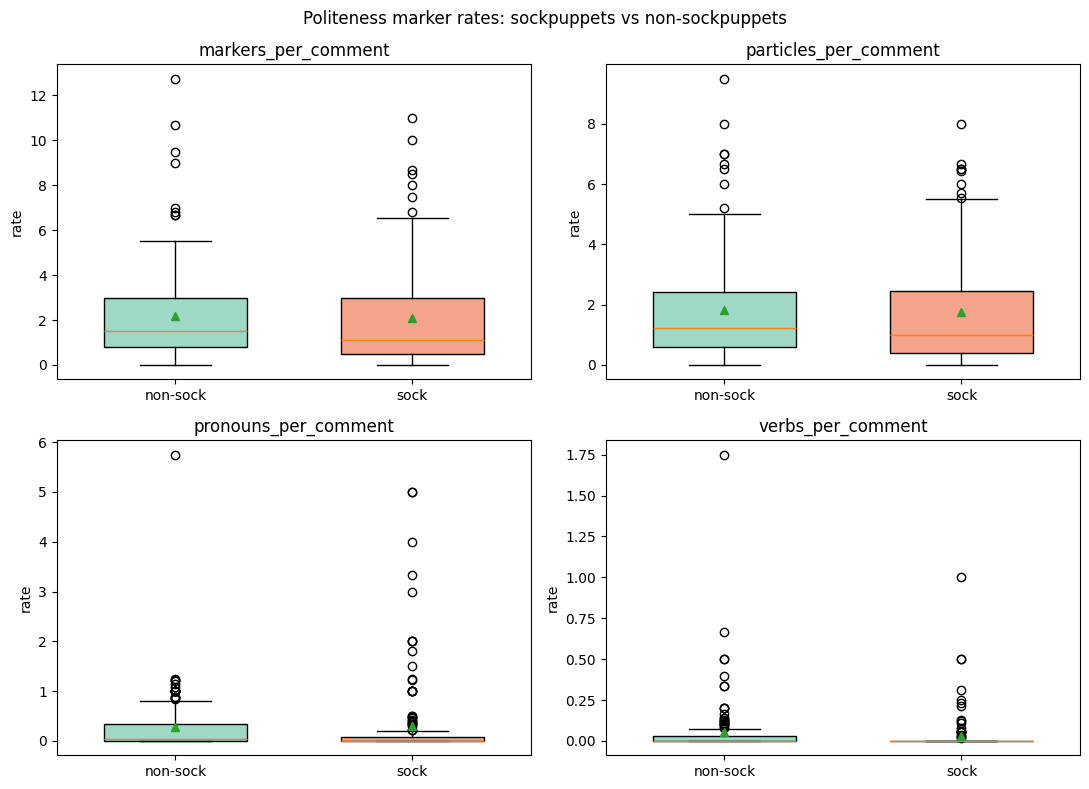

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
plot_cols = ['markers_per_comment', 'particles_per_comment',
             'pronouns_per_comment', 'verbs_per_comment']

for ax, col in zip(axes.flat, plot_cols):
    data = [non_sock[col].values, sock[col].values]
    bp = ax.boxplot(data, labels=['non-sock', 'sock'], showmeans=True,
                    patch_artist=True, widths=0.6)
    for patch, color in zip(bp['boxes'], ['#9fd8c5', '#f4a48b']):
        patch.set_facecolor(color)
    ax.set_title(col)
    ax.set_ylabel('rate')

fig.suptitle('Politeness marker rates: sockpuppets vs non-sockpuppets', fontsize=12)
plt.tight_layout()
plt.savefig('step1_register_plot.png', dpi=150, bbox_inches='tight')
plt.show()


## Cell 8 — Decision

In [8]:
best_disc = disc.iloc[0]
best_corr = corr.iloc[0]

p_thresh_strict, p_thresh_loose = 0.01, 0.05
rho_thresh = 0.3

discriminates_strict = bool(best_disc['p_value'] < p_thresh_strict)
discriminates_loose  = bool(best_disc['p_value'] < p_thresh_loose)
correlates           = bool(best_corr['abs_rho'] >= rho_thresh and best_corr['p_value'] < p_thresh_loose)

print('Best discrimination:')
print(f'  {best_disc["measure"]}: '
      f'sock={best_disc["sock_mean"]} vs non-sock={best_disc["nonsock_mean"]} '
      f'({best_disc["direction"]}, p={best_disc["p_value"]:.4g})')
print('Best correlation:')
print(f'  {best_corr["politeness"]} ~ {best_corr["structural"]}: '
      f'ρ={best_corr["spearman_rho"]} (p={best_corr["p_value"]:.4g})')
print()

if discriminates_strict and correlates:
    print('✅ STRONG SUPPORT — register hypothesis holds.')
    print('   The L-structural family captures the register/politeness signal indirectly.')
    print('   Include in thesis as a unified story with the 5/12 finding.')
elif discriminates_loose and not correlates:
    print('⚠ WEAK SUPPORT — register signal exists but is not captured by L-structural features.')
    print('   The 5/12 finding stands; the L-structural family works for a different reason.')
    print('   Do NOT claim a unified story. L-structural performance is a separate result.')
elif not discriminates_loose:
    print('❌ NO SUPPORT — politeness does not discriminate sock vs non-sock in this split.')
    print('   The 5/12 finding may have been specific to filtered subsets.')
    print('   Drop the unified-story claim. L-structural finding stands on its own.')
else:
    print('Mixed — manual review of the tables above is needed.')


Best discrimination:
  total_markers: sock=16.4714 vs non-sock=52.4357 (sock < non-sock, p=4.476e-07)
Best correlation:
  pronouns_count ~ repetition_sum: ρ=0.536 (p=3.18e-22)

✅ STRONG SUPPORT — register hypothesis holds.
   The L-structural family captures the register/politeness signal indirectly.
   Include in thesis as a unified story with the 5/12 finding.


## Done

Four files written:
- `step1_register_per_user.csv` — joined per-user politeness + structural features + label
- `step1_register_discrimination.csv` — Mann-Whitney U test results
- `step1_register_correlations.csv` — Spearman correlations
- `step1_register_plot.png` — boxplots

Cell 8 prints the decision. Whatever it says is what goes into the report — don't massage the framing if it comes back weak.

**One caveat to flag.** This analysis uses Karin's full mixed-topic dataset, matching her splits. The 5/12 register finding was observed under the same condition (mixed topics, not การเมือง-filtered). If discrimination is weak here, that's evidence against the unified story even though 5/12 reported it — possibly because the 5/12 analysis used a different feature representation (raw vocabulary vs. aggregated rates).